In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

torch.set_default_dtype(torch.float64)

Interface alignment error: 0.00e+00
n_fine=800, dt=2.5000e-03, tf=2.0
Solver(k1=1.0, k2=2.0, z_dis=1.0, Pda=1.0, Lz=16.0, nz=160, tf=2.0, n_t_out=80, device='cuda')
Keys: ['U', 'U_raw', 'W', 'dataset', 'interp', 'interp_lin', 'interp_pw', 'kratio', 'stau', 't', 'z', 'z_dis']
Flux condition error  max=2.956e-01  mean=2.047e-01


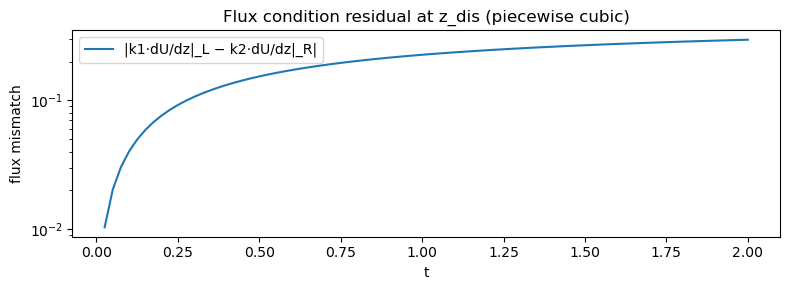

Running coarse solver...
Running fine reference solver...
Done.
Linear        max=3.355e-03  mean=1.490e-04
Cubic         max=3.731e-03  mean=2.073e-04
Piecewise     max=3.355e-03  mean=1.958e-04


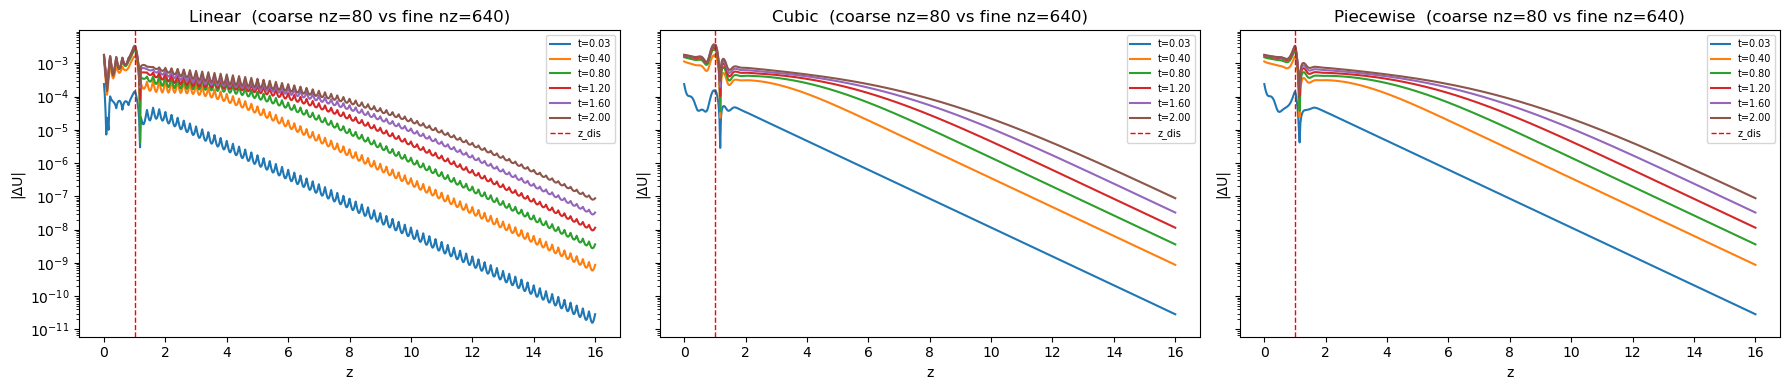

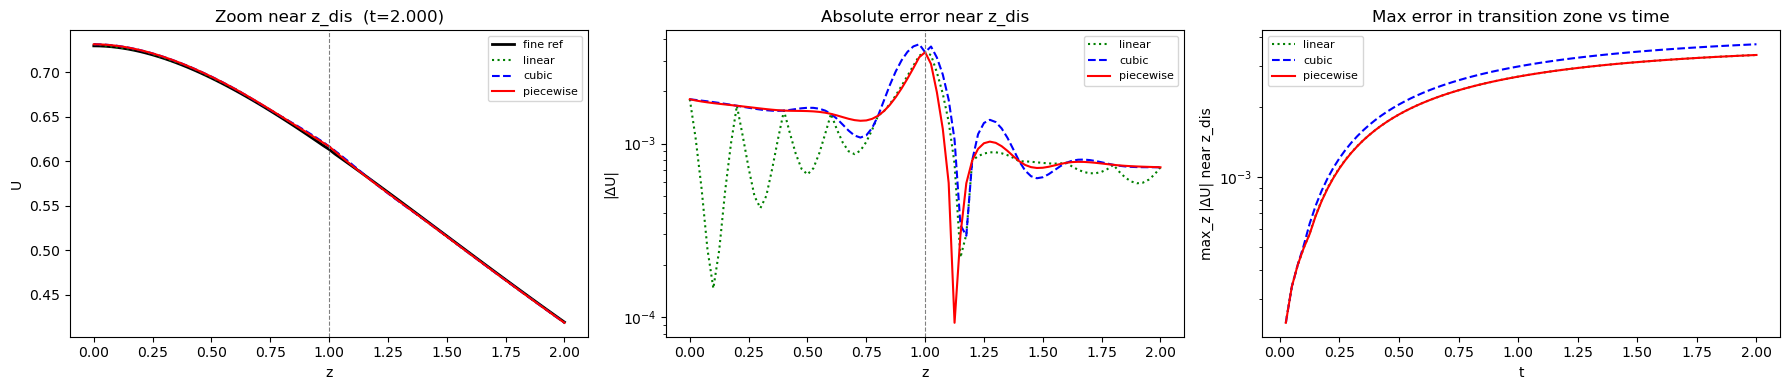

Dataset saved to ./data/2layer_k11.0_k22.0_nz160.pt


In [2]:
%run func_defs.ipynb
%run 2L_NN_v9.ipynb   # provides Solver, pt_2d_interpolation, pt_2d_interp_piecewise

## Parameters

`stride_list` controls how aggressively we downsample.
A stride of `s` keeps every `s`-th point in both `z` and `t`.

In [3]:
# ── fine solve parameters ────────────────────────────────────────────────
k1, k2    = 1.0, 2.0
z_dis     = 1.0
Pda       = 1.0
Lz        = 16.0
tf        = 2.0
nz_fine   = 640       # fine spatial grid
nt_fine   = 320       # fine temporal output points

# ── downsampling strides to compare ──────────────────────────────────────
# stride s -> coarse grid has (nz_fine//s + 1) z-points, (nt_fine//s) t-points
stride_list = [2, 4, 8, 16]

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {device}')
print(f'Fine grid: nz={nz_fine}, nt={nt_fine}')
print(f'Strides  : {stride_list}')
print(f'Coarse nz per stride: {[nz_fine // s for s in stride_list]}')

device: cuda
Fine grid: nz=640, nt=320
Strides  : [2, 4, 8, 16]
Coarse nz per stride: [320, 160, 80, 40]


## Run the fine solver (once)

In [4]:
sol_fine = Solver(
    k1=k1, k2=k2, z_dis=z_dis, Pda=Pda,
    Lz=Lz, nz=nz_fine, tf=tf, n_t_out=nt_fine,
    device=device, verbose=True,
)

z_fine = sol_fine['z']   # (nz_fine+1,)
t_fine = sol_fine['t']   # (nt_fine,)
U_fine = sol_fine['U']   # (nz_fine+1, nt_fine)  — smoothed, this is our truth

print(f'z_fine : {z_fine.shape}')
print(f't_fine : {t_fine.shape}')
print(f'U_fine : {U_fine.shape}')

Interface alignment error: 0.00e+00
n_fine=12800, dt=1.5625e-04, tf=2.0
z_fine : torch.Size([641])
t_fine : torch.Size([320])
U_fine : torch.Size([641, 320])


## Downsample helper

Takes every `sz`-th z-point and every `st`-th t-point from the fine arrays.
Returns the coarse `(z, t, U)` triple ready to pass to `pt_2d_interpolation`.

In [5]:
def downsample(z, t, U, sz=1, st=1):
    """
    Downsample the fine (z, t, U) arrays by integer strides.

    Parameters
    ----------
    z, t : 1-D tensors   fine spatial and temporal grids
    U    : 2-D tensor    U[i, j] = solution at (z[i], t[j])
    sz   : int           spatial stride  (keep every sz-th z point)
    st   : int           temporal stride (keep every st-th t point)

    Returns
    -------
    z_c, t_c, U_c : coarse grids and solution
    """
    z_c = z[::sz]
    t_c = t[::st]
    U_c = U[::sz, ::st]
    return z_c, t_c, U_c

# quick sanity check
z_c, t_c, U_c = downsample(z_fine, t_fine, U_fine, sz=4, st=4)
print(f'stride=4 → z_c: {z_c.shape}, t_c: {t_c.shape}, U_c: {U_c.shape}')

stride=4 → z_c: torch.Size([161]), t_c: torch.Size([80]), U_c: torch.Size([161, 80])


## Build interpolants from downsampled data

For each stride, we build three interpolants from the coarse grid and
evaluate them at every point on the original fine `(z, t)` grid.

In [6]:
# pre-build the fine 2-D query grid (stays fixed across all strides)
z_f2d, t_f2d = torch.meshgrid(z_fine, t_fine, indexing='ij')

results = {}   # stride -> {'lin', 'cub', 'pw'}  each (nz_fine+1, nt_fine)

for s in stride_list:
    z_c, t_c, U_c = downsample(z_fine, t_fine, U_fine, sz=s, st=s)
    print(f'stride={s:2d}  coarse shape: z={z_c.shape[0]}, t={t_c.shape[0]}')

    # build the three interpolants on the coarse data
    fn_lin = pt_2d_interpolation(z_c, t_c, U_c, kx=1, ky=1, s=0)
    fn_cub = pt_2d_interpolation(z_c, t_c, U_c, kx=3, ky=3, s=0)
    fn_pw  = pt_2d_interp_piecewise(z_c, t_c, U_c, z_dis, kx=3, ky=3, s=0)

    # evaluate on the full fine grid
    U_lin = fn_lin(z_f2d, t_f2d)
    U_cub = fn_cub(z_f2d, t_f2d)
    U_pw  = fn_pw (z_f2d, t_f2d)

    results[s] = {
        'lin': (U_lin - U_fine).abs(),
        'cub': (U_cub - U_fine).abs(),
        'pw' : (U_pw  - U_fine).abs(),
    }

print('\nSummary  (max absolute error on full fine grid):')
print(f'  {"stride":>8}  {"linear":>12}  {"cubic":>12}  {"piecewise":>12}')
print('-' * 52)
for s, res in results.items():
    print(f'  {s:>8d}  {res["lin"].max().item():>12.4e}'
          f'  {res["cub"].max().item():>12.4e}'
          f'  {res["pw"].max().item():>12.4e}')

stride= 2  coarse shape: z=321, t=160
stride= 4  coarse shape: z=161, t=80


/tmp/ipykernel_123/1504667832.py:15: UserWarning: torch.searchsorted(): boundary tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous boundary tensor if possible. This message will only appear once per program. (Triggered internally at ../aten/src/ATen/native/BucketizationUtils.h:38.)
  m = torch.searchsorted(


stride= 8  coarse shape: z=81, t=40
stride=16  coarse shape: z=41, t=20

Summary  (max absolute error on full fine grid):
    stride        linear         cubic     piecewise
----------------------------------------------------
         2    1.7310e-03    1.6217e-03    1.6217e-03
         4    5.2930e-03    4.8725e-03    4.8725e-03
         8    1.2961e-02    1.1410e-02    1.1413e-02
        16    2.9913e-02    2.4830e-02    5.5677e-02


## Plots

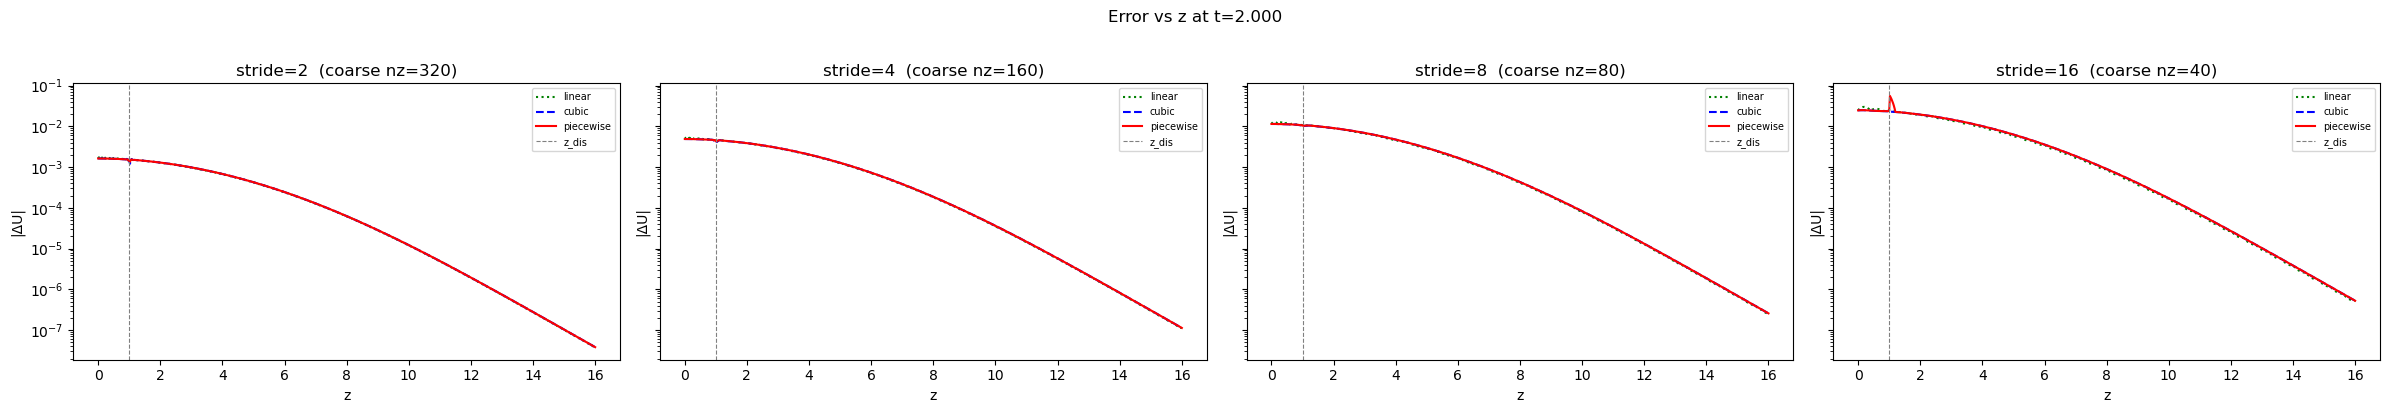

In [7]:
# ── error profiles along z at the last time step ─────────────────────────
i_last = nt_fine - 1
z_cpu  = z_fine.cpu()
t_cpu  = t_fine.cpu()

fig, axes = plt.subplots(1, len(stride_list),
                         figsize=(6 * len(stride_list), 4), sharey=True)

for ax, s in zip(axes, stride_list):
    res = results[s]
    ax.semilogy(z_cpu, res['lin'][:, i_last].cpu().clamp(min=1e-16),
                'g:', lw=1.5, label='linear')
    ax.semilogy(z_cpu, res['cub'][:, i_last].cpu().clamp(min=1e-16),
                'b--', lw=1.5, label='cubic')
    ax.semilogy(z_cpu, res['pw' ][:, i_last].cpu().clamp(min=1e-16),
                'r-',  lw=1.5, label='piecewise')
    ax.axvline(z_dis, color='gray', linestyle='--', lw=0.8, label='z_dis')
    ax.set_xlabel('z'); ax.set_ylabel('|ΔU|')
    ax.set_title(f'stride={s}  (coarse nz={nz_fine//s})')
    ax.legend(fontsize=7)

plt.suptitle(f'Error vs z at t={t_cpu[i_last]:.3f}', y=1.02)
plt.tight_layout(); plt.show()

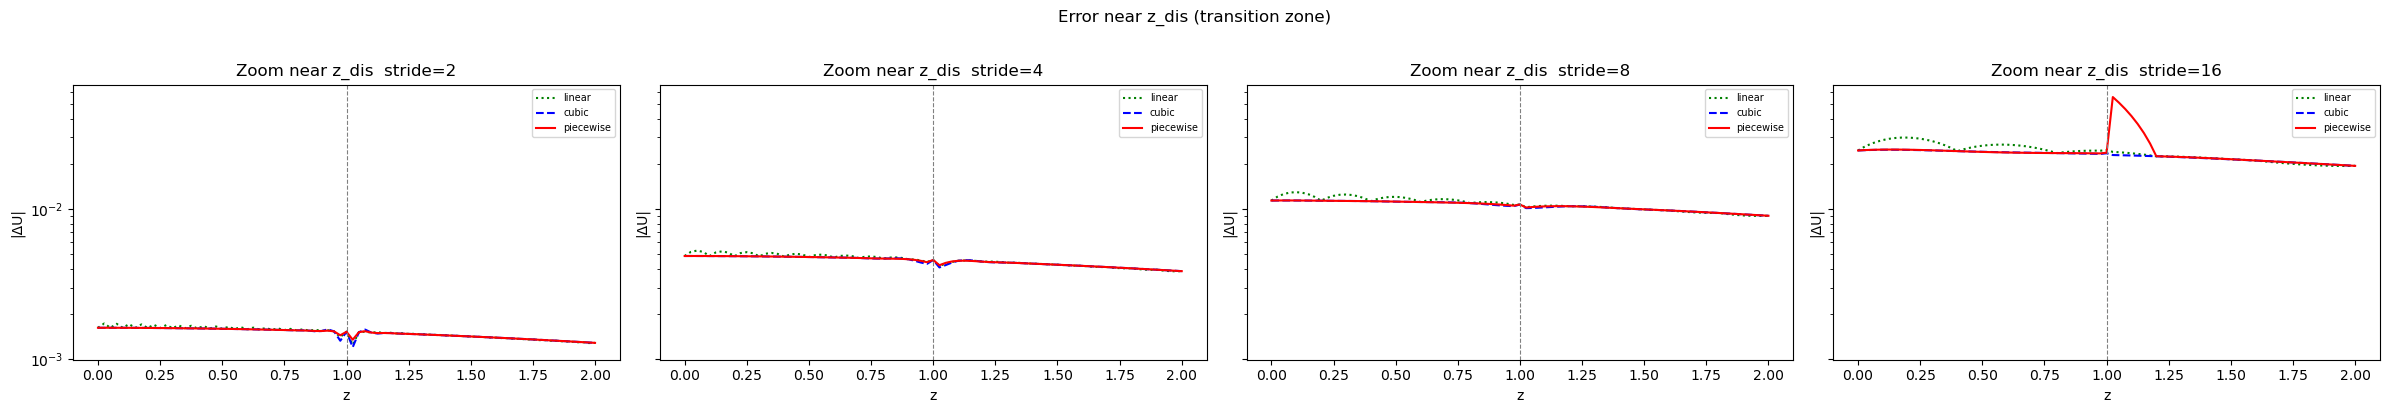

In [8]:
# ── zoom near z_dis at last time step ────────────────────────────────────
w   = nz_fine // 16
m_f = torch.searchsorted(z_fine, torch.tensor(z_dis, device=z_fine.device)).item()
sl  = slice(max(0, m_f - w), min(len(z_fine), m_f + w + 1))
z_z = z_fine[sl].cpu()

fig, axes = plt.subplots(1, len(stride_list),
                         figsize=(6 * len(stride_list), 4), sharey=True)

for ax, s in zip(axes, stride_list):
    res = results[s]
    ax.semilogy(z_z, res['lin'][sl, i_last].cpu().clamp(min=1e-16),
                'g:', lw=1.5, label='linear')
    ax.semilogy(z_z, res['cub'][sl, i_last].cpu().clamp(min=1e-16),
                'b--', lw=1.5, label='cubic')
    ax.semilogy(z_z, res['pw' ][sl, i_last].cpu().clamp(min=1e-16),
                'r-',  lw=1.5, label='piecewise')
    ax.axvline(z_dis, color='gray', linestyle='--', lw=0.8)
    ax.set_xlabel('z'); ax.set_ylabel('|ΔU|')
    ax.set_title(f'Zoom near z_dis  stride={s}')
    ax.legend(fontsize=7)

plt.suptitle('Error near z_dis (transition zone)', y=1.02)
plt.tight_layout(); plt.show()

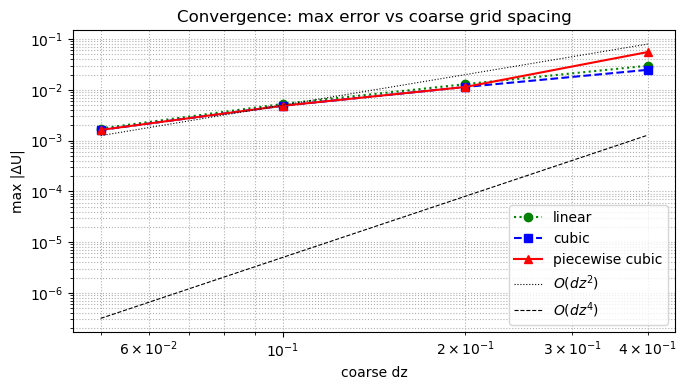

In [15]:
# ── max error vs coarse dz (convergence rate plot) ───────────────────────
dz_fine  = (Lz / nz_fine)
dz_list  = [dz_fine * s for s in stride_list]

max_lin = [results[s]['lin'].max().item() for s in stride_list]
max_cub = [results[s]['cub'].max().item() for s in stride_list]
max_pw  = [results[s]['pw' ].max().item() for s in stride_list]

dz_arr = np.array(dz_list)

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(dz_arr, max_lin, 'g:o',  label='linear')
ax.loglog(dz_arr, max_cub, 'b--s', label='cubic')
ax.loglog(dz_arr, max_pw,  'r-^',  label='piecewise cubic')

# reference slopes
ref = dz_arr
ax.loglog(dz_arr, 0.5  * ref**2, 'k:',  lw=0.8, label=r'$O(dz^2)$')
ax.loglog(dz_arr, 0.05 * ref**4, 'k--', lw=0.8, label=r'$O(dz^4)$')

ax.set_xlabel('coarse dz'); ax.set_ylabel('max |ΔU|')
ax.set_title('Convergence: max error vs coarse grid spacing')
ax.legend(); ax.grid(True, which='both', linestyle=':')
plt.tight_layout(); plt.show()

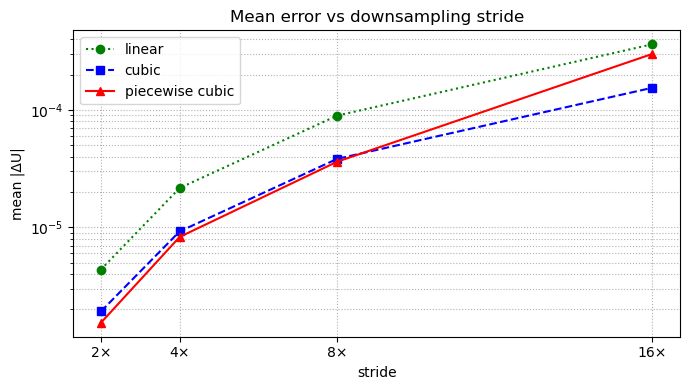

In [16]:
# ── mean error vs stride (all three methods, stacked bar feel) ───────────
mean_lin = [results[s]['lin'].mean().item() for s in stride_list]
mean_cub = [results[s]['cub'].mean().item() for s in stride_list]
mean_pw  = [results[s]['pw' ].mean().item() for s in stride_list]

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(stride_list, mean_lin, 'g:o',  label='linear')
ax.semilogy(stride_list, mean_cub, 'b--s', label='cubic')
ax.semilogy(stride_list, mean_pw,  'r-^',  label='piecewise cubic')
ax.set_xlabel('stride'); ax.set_ylabel('mean |ΔU|')
ax.set_title('Mean error vs downsampling stride')
ax.set_xticks(stride_list, [f'{s}×' for s in stride_list])
ax.legend(); ax.grid(True, which='both', linestyle=':')
plt.tight_layout(); plt.show()